## Import Libraries

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential , load_model
from tensorflow.keras.layers import Conv2D , Dense , MaxPool2D , Input , Flatten , Dropout , Rescaling , BatchNormalization
from tensorflow.keras.activations import relu , softmax
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.resnet50 import ResNet50 , preprocess_input
from tensorflow.data import Dataset , AUTOTUNE

## Load Dataset & Preprocessing

In [2]:
(X_train , y_train) , (X_test , y_test) = cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 905s 5us/step


In [3]:
print(f"X_train shape => {X_train.shape}")
print(f"y_train shape => {y_train.shape}")

print(f"X_test shape => {X_test.shape}")
print(f"y_test shape => {y_test.shape}")

X_train shape => (50000, 32, 32, 3)
y_train shape => (50000, 1)
X_test shape => (10000, 32, 32, 3)
y_test shape => (10000, 1)


In [4]:
print(f"Classes names => {np.unique(y_train)}")

Classes names => [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95
 96 97 98 99]


In [5]:
output_size = len(np.unique(y_train))

output_size

100

Plot sample of X_train

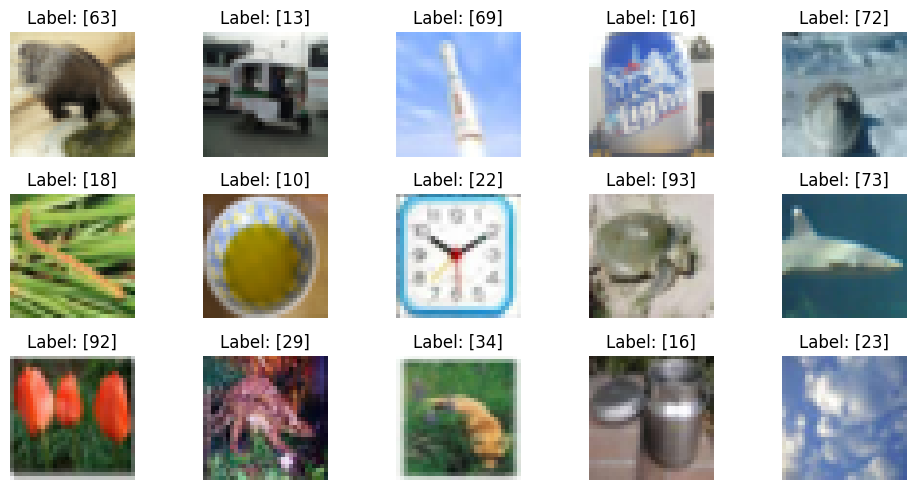

In [7]:
np.random.seed(42)
tf.random.set_seed(42)

fig , ax = plt.subplots(3,5,figsize = (10,5))
sample_idx = np.random.choice(len(X_train) , size=15 , replace=False)

for axes , idx in zip(ax.flat , sample_idx):
    axes.imshow(X_train[idx])
    axes.set_title(f"Label: {y_train[idx]}")

    axes.axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Use 10% for validation
val_size = int(len(X_train) * 0.1)
val_size

5000

In [9]:
X_val = X_train[ : val_size]
y_val = y_train[ : val_size]

X_train = X_train[val_size: ]
y_train = y_train[val_size: ]

print(f"X_train shape => {X_train.shape}")
print(f"y_train shape => {y_train.shape}")

print(f"X_val shape => {X_val.shape}")
print(f"y_val shape => {y_val.shape}")

X_train shape => (45000, 32, 32, 3)
y_train shape => (45000, 1)
X_val shape => (5000, 32, 32, 3)
y_val shape => (5000, 1)


## CNN Model From Scratch

In [10]:
input_shape = X_train.shape[1:]

input_shape

(32, 32, 3)

In [11]:
cnn_model = Sequential([
    Input(shape=input_shape),
    Rescaling(1. / 255),

    # Conv Block 1
    Conv2D(32, (4,4), activation=relu, padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.1),

    # Conv Block 2
    Conv2D(128, (4,4), activation=relu, padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.3),

    # Conv Block 3
    Conv2D(256, (4,4), activation=relu, padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.3),

    # Conv Block 4
    Conv2D(80, (4,4), activation=relu, padding="same"),
    BatchNormalization(),
    MaxPool2D(),
    Dropout(0.15),

    # Conv Block 5
    Conv2D(64, (4,4), activation=relu, padding="same"),
    BatchNormalization(),
    Dropout(0.16),

    # Conv Block 6
    Conv2D(60, (3,3), activation=relu, padding="same"),
    BatchNormalization(),
    Dropout(0.1),

    # Conv Block 7
    Conv2D(55, (3,3), activation=relu, padding="same"),
    BatchNormalization(),
    Dropout(0.1),

    # Conv Block 8
    Conv2D(32, (3,3), activation=relu, padding="same"),
    BatchNormalization(),
    Dropout(0.05),

    Flatten(),

    Dense(128, activation=relu),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation=relu),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16, activation=relu),
    BatchNormalization(),
    Dropout(0.1),

    Dense(output_size, activation=softmax)
], name="Scratch_CNN_Model")

cnn_model.summary()

Model: "Scratch_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 128)    │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 80)       │       327,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 80)       │           320 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 80)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2, 2, 80)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 64)       │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 60)       │        34,620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2, 2, 60)       │           240 │
│ (BatchNormalization)            │                        │             

 Total params: 1,112,935 (4.25 MB)

 Trainable params: 1,111,105 (4.24 MB)

 Non-trainable params: 1,830 (7.15 KB)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    verbose=0,
    restore_best_weights=True
)

In [13]:
cnn_model.compile(
    optimizer = Adam(),
    loss = SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

In [14]:
history_clf1 = cnn_model.fit(
    X_train , y_train,
    validation_data = (X_val , y_val),
    epochs = 50,
    verbose = 1,
    callbacks = [early_stop]
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 52s 21ms/step - accuracy: 0.0372 - loss: 4.3162 - val_accuracy: 0.0602 - val_loss: 4.0233
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.0664 - loss: 4.0029 - val_accuracy: 0.0680 - val_loss: 4.0019
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.0914 - loss: 3.8054 - val_accuracy: 0.0952 - val_loss: 3.8155
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1229 - loss: 3.6057 - val_accuracy: 0.1282 - val_loss: 3.6951
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1502 - loss: 3.4432 - val_accuracy: 0.1778 - val_loss: 3.3211
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1756 - loss: 3.2944 - val_accuracy: 0.2092 - val_loss: 3.1369
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.1996 - loss: 3.1644 - val_accuracy: 0.2266 - val_loss: 3.0520
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.2208 - loss: 

In [15]:
# save model
cnn_model.save("Scratch_CNN_Model.keras")

## Pretrained Model — ResNet50

In [16]:
img_size = 94

In [17]:
X_train.shape

(45000, 32, 32, 3)

In [18]:
base_model = ResNet50(
    weights = "imagenet",
    include_top = False,
    input_shape = (img_size , img_size , 3),
    pooling = "avg"
)

base_model.trainable = False

base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 94, 94, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 100, 100,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 47, 47,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 47, 47,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 47, 47,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 49, 49,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 24, 24,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 24, 24,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [19]:
def build_head():
    model = Sequential([
        base_model,

        Dense(128 , activation=relu),
        Dropout(0.3),

        Dense(64 , activation=relu),
        Dropout(0.2),

        Dense(32 , activation=relu),
        Dropout(0.15),

        Dense(16 , activation = relu),
        Dropout(0.1),

        # Output layer
        Dense(units=output_size , activation=softmax)
    ])

    model.compile(
        optimizer = Adam(),
        loss = SparseCategoricalCrossentropy(),
        metrics = ['accuracy']
    )

    return model

In [20]:
pretrained_model = build_head()

pretrained_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2048)           │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │         1,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,862,548 (91.03 MB)

 Trainable params: 274,836 (1.05 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
def resnet_pipeline(X, y, batch_size=300, shuffle=False):
  # Dataset -> Tensorflow Dataset
    ds = Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10000), seed=42)

    # Resize
    ds = ds.map(
        lambda img, label: (tf.image.resize(tf.cast(img, tf.float32), (img_size, img_size)), label),
                num_parallel_calls=AUTOTUNE)

    # preprocess input
    ds = ds.map(lambda img, label: (preprocess_input(img), label), num_parallel_calls=AUTOTUNE)

    ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(X), 10000), seed=42)

    return ds.batch(batch_size).prefetch(AUTOTUNE)

In [22]:
train_ds = resnet_pipeline(X_train, y_train, shuffle=True)
val_ds = resnet_pipeline(X_val, y_val)
test_ds = resnet_pipeline(X_test, y_test)

In [23]:
early_stop2 = EarlyStopping(
    monitor="val_loss",
    patience=10,
    verbose=0,
    restore_best_weights=True
)

In [24]:
history_clf2 = pretrained_model.fit(
    train_ds ,
    validation_data = (val_ds),
    epochs = 50,
    verbose = 1,
    callbacks = [early_stop2]
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 305ms/step - accuracy: 0.0599 - loss: 4.2419 - val_accuracy: 0.2226 - val_loss: 3.2306
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.1894 - loss: 3.1920 - val_accuracy: 0.3682 - val_loss: 2.4312
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 30s 202ms/step - accuracy: 0.2588 - loss: 2.7529 - val_accuracy: 0.4246 - val_loss: 2.1900
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 205ms/step - accuracy: 0.3022 - loss: 2.5217 - val_accuracy: 0.4508 - val_loss: 2.0200
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 204ms/step - accuracy: 0.3365 - loss: 2.3754 - val_accuracy: 0.4630 - val_loss: 1.9773
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 205ms/step - accuracy: 0.3620 - loss: 2.2629 - val_accuracy: 0.4860 - val_loss: 1.8911
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 205ms/step - accuracy: 0.3832 - loss: 2.1619 - val_accuracy: 0.4960 - val_loss: 1.8445
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.4004 - loss: 2

In [25]:
pretrained_model.save("Pretrained_model.keras")

##  Evaluation & Results

In [26]:
# Scratch model test
test_loss1 , test_acc1 = cnn_model.evaluate(X_test , y_test)

print(f"Test loss => {test_loss1}")
print(f"Test acc => {test_acc1 *100:.2f} %")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4296 - loss: 2.2278
Test loss => 2.227754592895508
Test acc => 42.96 %


In [27]:
# Scratch model train and val acc
print(f"Train acc  => {history_clf1.history['accuracy'][-1] * 100:.2f} %")
print(f"Val acc    => {history_clf1.history['val_accuracy'][-1] * 100:.2f} %")
print(f"Train loss => {history_clf1.history['loss'][-1]:.4f}")
print(f"Val loss   => {history_clf1.history['val_loss'][-1]:.4f}")

Train acc  => 50.74 %
Val acc    => 42.22 %
Train loss => 1.7659
Val loss   => 2.3207


In [28]:
# Resnet50 model test
test_loss2 , test_acc2 = pretrained_model.evaluate(test_ds)

print(f"Test loss => {test_loss2}")
print(f"Test acc => {test_acc2 *100:.2f} %")

34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 339ms/step - accuracy: 0.5707 - loss: 1.6633
Test loss => 1.6633285284042358
Test acc => 57.07 %


In [29]:
# Resnet50 model train and val acc
print(f"Train acc  => {history_clf2.history['accuracy'][-1] * 100:.2f} %")
print(f"Val acc    => {history_clf2.history['val_accuracy'][-1] * 100:.2f} %")
print(f"Train loss => {history_clf2.history['loss'][-1]:.4f}")
print(f"Val loss   => {history_clf2.history['val_loss'][-1]:.4f}")

Train acc  => 56.34 %
Val acc    => 57.76 %
Train loss => 1.4387
Val loss   => 1.6965


Plots

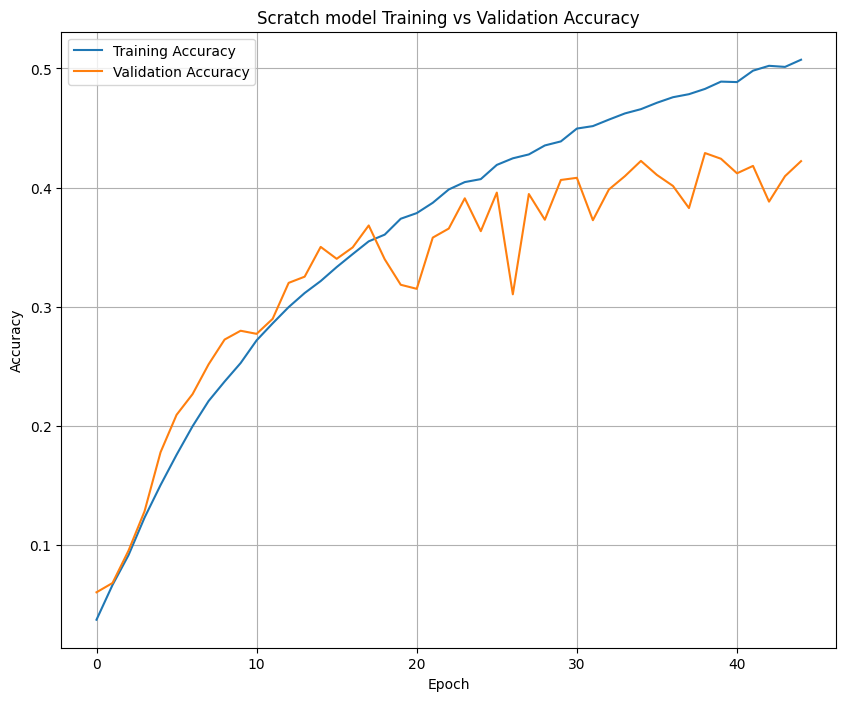

In [30]:
# Scratch model
plt.figure(figsize = (10,8))

plt.plot(history_clf1.history["accuracy"], label="Training Accuracy")
plt.plot(history_clf1.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Scratch model Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

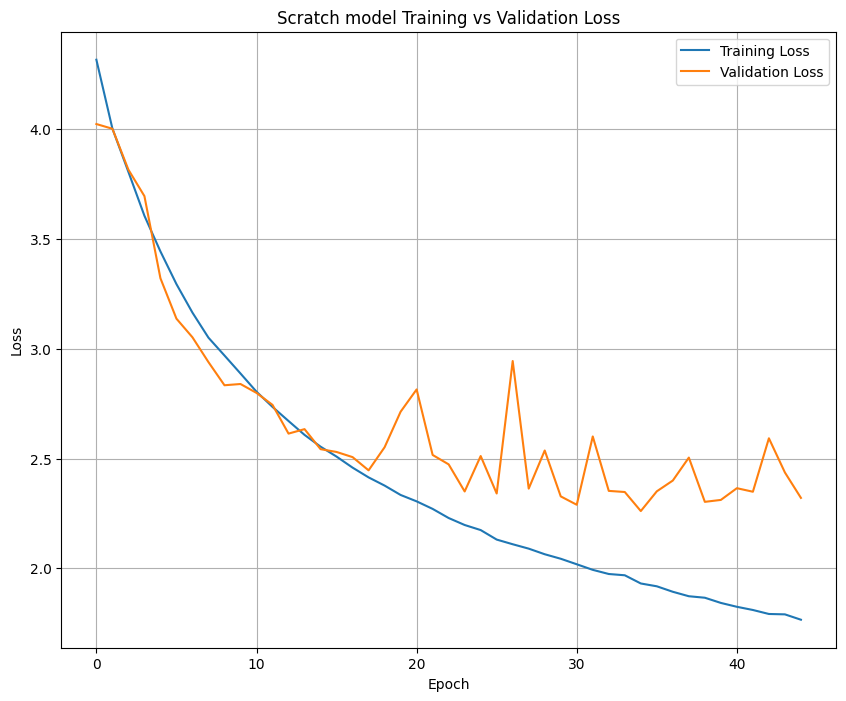

In [31]:
# Scratch model
plt.figure(figsize = (10,8))

plt.plot(history_clf1.history["loss"], label="Training Loss")
plt.plot(history_clf1.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scratch model Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

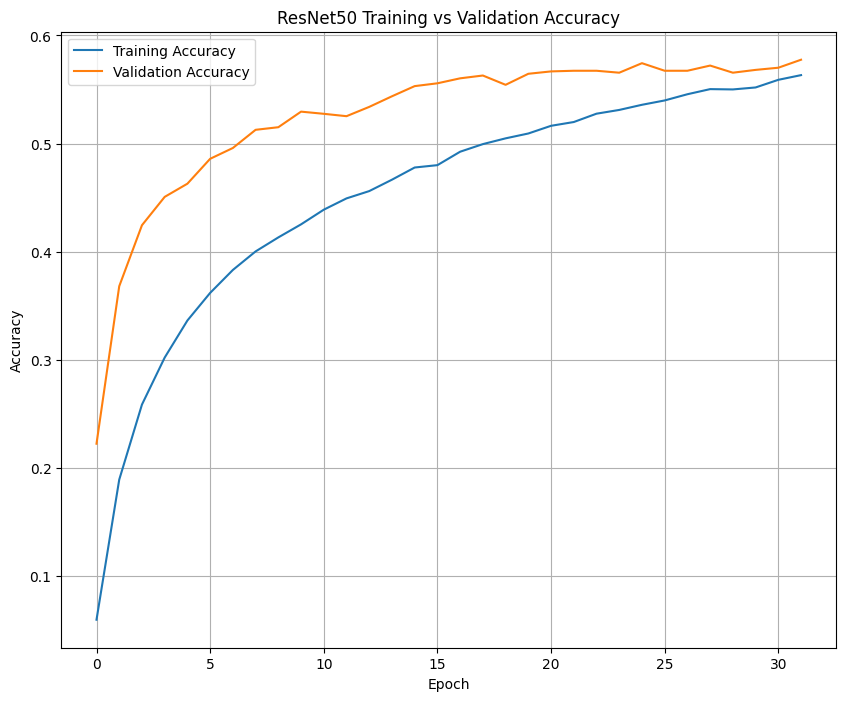

In [32]:
# Resnet50 model
plt.figure(figsize = (10,8))

plt.plot(history_clf2.history["accuracy"], label="Training Accuracy")
plt.plot(history_clf2.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

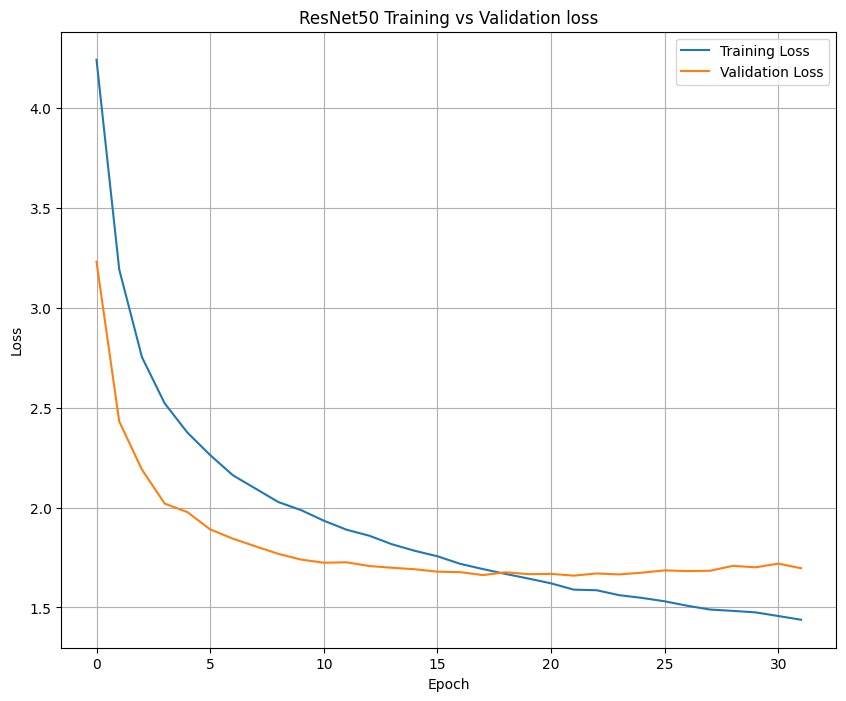

In [33]:
# Resnet50 model
plt.figure(figsize = (10,8))

plt.plot(history_clf2.history["loss"], label="Training Loss")
plt.plot(history_clf2.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training vs Validation loss")
plt.legend()
plt.grid(True)

plt.show()

## Comparison

In [35]:
comparison = pd.DataFrame({
    "Metric": [
        "Train Accuracy",
        "Validation Accuracy",
        "Test Accuracy",
        "Test Loss",
        "Training Time",
        "Number of Parameters"
    ],
    "Scratch CNN": [
        history_clf1.history['accuracy'][-1],
        history_clf1.history['val_accuracy'][-1],
        test_acc1,
        test_loss1,
        "638  seconds",
        "1,112,935"

    ],
    "ResNet50": [
      history_clf2.history['accuracy'][-1],
      history_clf2.history['val_accuracy'][-1],
      test_acc2,
      test_loss2,
      "1000 seconds",
      "23,862,548"
    ]
})

comparison

,Metric,Scratch CNN,ResNet50
0,Train Accuracy,0.507356,0.563356
1,Validation Accuracy,0.4222,0.5776
2,Test Accuracy,0.4296,0.5707
3,Test Loss,2.227755,1.663329
4,Training Time,638 seconds,1000 seconds
5,Number of Parameters,"1,112,935","23,862,548"


## Conclusion

Overall, the **ResNet50 pretrained model performed better than the Scratch CNN**. ResNet50 achieved a higher validation accuracy (**57.76% vs. 42.22%**) and test accuracy (**57.07% vs. 42.96%**), while also achieving a lower test loss (**1.6633 vs. 2.2278**). Although ResNet50 required more training time (**1000 vs. 638 seconds**) and had significantly more parameters, its better performance shows the benefit of using pretrained features.

Using a pretrained model such as ResNet50 provides **transfer learning**, allowing the model to start with features learned from a large dataset instead of learning everything from scratch. This can improve accuracy, generalization, and convergence, especially when the available dataset is limited. Therefore, **ResNet50 is the better-performing model for this task**.
